# Jeu de traces simulées à partir d'un réseau

Nous présentons ici un exemple simple et complet reposant sur une collection de traces simulées à partir d’un réseau. 

Ce pipeline est exécuté en une seule itération.

Le réseau est un extrait de la BDTOPO située sur un versant de montagne en face de la ville de Chamonix, il représente un cas non complexe de tronçons.

## Import des librairies

In [1]:
import os
import sys

import matplotlib.pyplot as plt

# Import de tracklib
module_path = os.path.abspath(os.path.join('../../../../tracklib'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Import de OFNP
module_path = os.path.abspath(os.path.join('../../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import tracklib as tkl

## Données : réseau puis traces simulées

Number of edges= 7
Number of nodes= 8



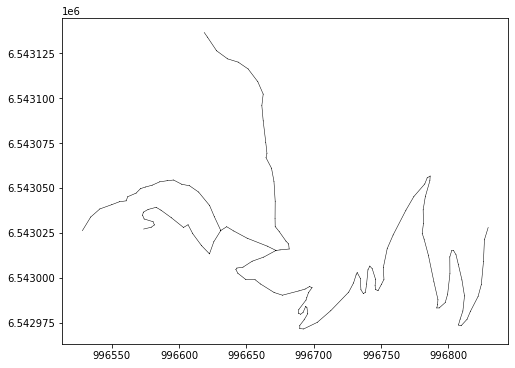

In [2]:
# WKT;link_id;source;target;direction;wkt_source;wkt_target
fmt = tkl.NetworkFormat({
       "pos_edge_id": 1,
       "pos_source": 2,
       "pos_target": 3,
       "pos_wkt": 0,
       "srid": "ENU",
       "separator": ";",
       "header": 1})
netpath = os.path.abspath(os.path.join('../../../data/network2.csv'))
network = tkl.NetworkReader.readFromFile(netpath, fmt, verbose=False)

plt.figure(figsize=(8, 6))
network.plot('k-', '', 'g-', 'r-', 0.5, plt)

print ('Number of edges=', len(network.EDGES))
print ('Number of nodes=', len(network.NODES))
print ('')

100% (250 of 250) |######################| Elapsed Time: 0:00:05 Time:  0:00:050000


------------------------------------------------------------
225 (90.0 %) tracks generated on network
------------------------------------------------------------


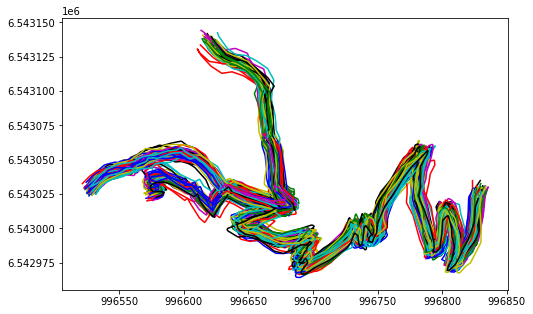

In [3]:
#
noiser = tkl.NoiseProcess(amps=3, kernels=tkl.ExponentialKernel(100))

# generate simulated trajectories from the network 
collection = tkl.generateTracksOnNetwork(network, N=250, p_round_trip=0.05, p_cplx_trip=0.10, resolution=1, noiser=noiser)

# add 3 attributes
for idx, track in enumerate(collection):
    track.createAnalyticalFeature('num', idx+1)
    track.createAnalyticalFeature('user_id', idx+1)
    track.createAnalyticalFeature('track_id', idx+1)
#
plt.figure(figsize=(8, 5))
collection.plot(append=plt)

## Dossier de stockage des résultats

In [4]:
from ofnp import setupenv

RESPATH = r'/home/md_vandamme/4_RESEAU/ZTEMP/'

setupenv(RESPATH)


## Step 1 : segment and resample

In [5]:
from ofnp import segmentation_resample

# Paramètre : Nombre de points minimum pour un morceau de trace au moment du découpage
#             si le nombre n'est pas atteint, le morceau de trace est oublié
NB_OBS_MIN           = 10

# Paramètre : Distance en mètres entre 2 points, si supérieure au seuil on coupe la trace
DIST_MAX_2OBS        = 50


RESAMPLE_SIZE_GRID = 1
RESAMPLE_SIZE_FUSION = 5

# =============================================================================
#  On définit un format pour le stockage des traces modifiées dans le pipeline
fmt = tkl.TrackFormat({'ext': 'CSV',
                           'srid': 'ENU',
                           'id_E': 1, 'id_N': 0, 'id_U': 3, 'id_T': 2,
                           'time_fmt': '2D/2M/4Y 2h:2m:2s',
                           'separator': ';',
                           'header': 0,
                           'cmt': '#',
                           'read_all': True})
segmentation_resample(RESPATH, collection, fmt, NB_OBS_MIN, DIST_MAX_2OBS,
                    RESAMPLE_SIZE_GRID, RESAMPLE_SIZE_FUSION)



Starting segmentation and resampling...
Starting segmentation ...
    Number of tracks after segmentation: 225
Finished saving segmented tracks.
Starting resampling ...
    Number of tracks to resample:  225
    Number of tracks after resampling: 225
    Number of tracks after resampling: 225
Finished saving resampled tracks.
Stage 1 finished: segmentation and resampling.


## Step 2 : calculs des cartes de densités, de constraste et binaire

In [6]:
from ofnp import density_polygonize

RESAMPLE_SIZE_GRID = 1

G1_SIZE = 2
G2_SIZE = 30

SEUIL_DENSITE = 250  # 
SEUIL_SURFACE = 1000 # m2 - 50000 - 7000

cut_factor = 2

# =============================================================================
#
density_polygonize(RESPATH, G1_SIZE, G2_SIZE, SEUIL_DENSITE, SEUIL_SURFACE,
                       prefix='PT', rep='resample_grid', cut_factor=cut_factor)



Starting rasterization and vectorization
    Number of tracks to load:  225
Starting heatmap computation ...
    Execution time (seconds): 1.550269365310669
    Finished heatmap computation.
Starting morphological opening ...


100% (1519 of 1519) |####################| Elapsed Time: 0:00:00 Time:  0:00:00


    Execution time (seconds): 0.23081564903259277
    Finished morphological opening.
Vectorizing ...
    Execution time (seconds): 0.02220320701599121
    Vectorization completed.
Smoothing polygon to remove stair-step artifacts ...
    Execution time (seconds): 0.07221317291259766
    Road surface smoothing completed.
Starting centerline computation ...
    Execution time (seconds): 0.14055705070495605
    Centerline computed.
Stage 2 completed: rasterization and vectorization.


Text(0.5, 1.0, 'Road surface lissée')

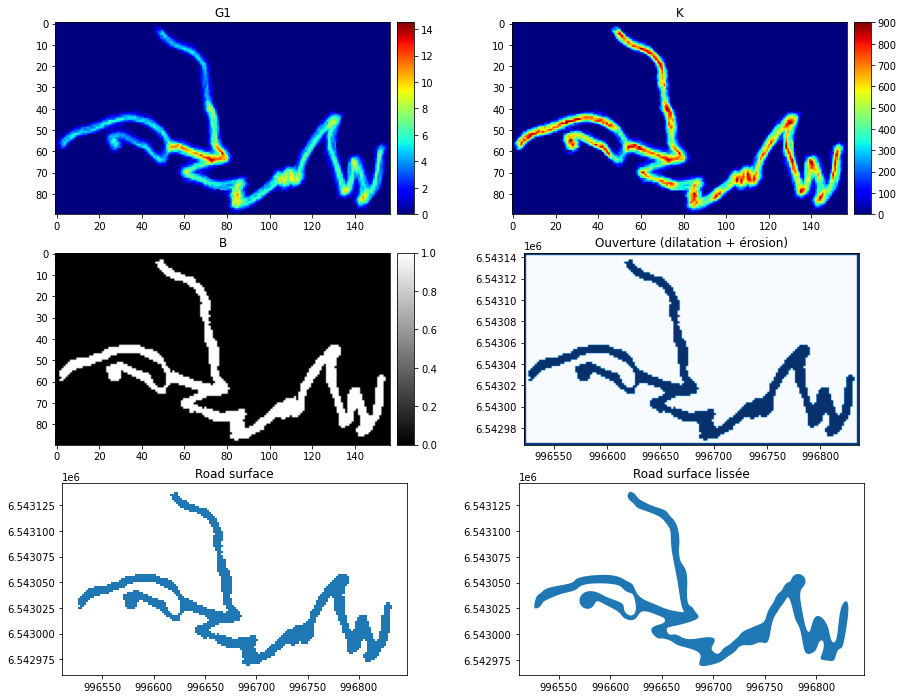

In [7]:
from ofnp import matPlotShapefile, matPlotRasterShp, maPlotRasterTiff

plt.figure(figsize=(15, 12))

# ----------------------------------------------------------------------------------------------------------
ax1 = plt.subplot2grid((3, 2), (0, 0))
rasterG1 = tkl.RasterReader.readFromAscFile(RESPATH + 'image/G1_PT.asc', name='G1', separator='\t')
mapDensity = rasterG1.getAFMap('G1')
mapDensity.plotAsImage(cmap='jet', vmin=0, append=ax1)

# ----------------------------------------------------------------------------------------------------------
ax2 = plt.subplot2grid((3, 2), (0, 1))
rasterK = tkl.RasterReader.readFromAscFile(RESPATH + 'image/K_PT.asc', name='K', separator='\t')
mapContraste = rasterK.getAFMap('K')
mapContraste.plotAsImage(cmap='jet', append=ax2)

# ----------------------------------------------------------------------------------------------------------
ax3 = plt.subplot2grid((3, 2), (1, 0))
rasterB = tkl.RasterReader.readFromAscFile(RESPATH + 'image/B_PT.asc', name='B', separator='\t')
mapBinaire = rasterB.getAFMap('B')
mapBinaire.plotAsImage(append=ax3)

# ----------------------------------------------------------------------------------------------------------
ax4 = plt.subplot2grid((3, 2), (1, 1))
maPlotRasterTiff(RESPATH, 'image/erosion_PT.tif', ax4)
ax4.set_title('Ouverture (dilatation + érosion)')

# ----------------------------------------------------------------------------------------------------------
ax5 = plt.subplot2grid((3, 2), (2, 0))
matPlotRasterShp(RESPATH, 'image/road_surface_PT.shp', ax5)
ax5.set_title('Road surface')

# ----------------------------------------------------------------------------------------------------------
ax6 = plt.subplot2grid((3, 2), (2, 1))
matPlotRasterShp(RESPATH, 'image/road_surface_lissee_PT.shp', ax6)
ax6.set_title('Road surface lissée')

## Step 3 : création de la center line

In [8]:
from ofnp import addTopologyToNetwork

DIST_MIN_ARC  = 50
addTopologyToNetwork(RESPATH, DIST_MIN_ARC)

fmt = tkl.NetworkFormat({
           "pos_edge_id": 0,
           "pos_source": 1,
           "pos_target": 2,
           "pos_wkt": 4,
           "srid": "ENU",
           "separator": ",",
           "header": 1})
    
networkpath = RESPATH + 'network/reseau_PT.csv'
squelette = tkl.NetworkReader.readFromFile(networkpath, fmt, verbose=False)

Starting topology creation for the network
    Number of edges in the smoothed skeleton: 299
    Finished loaded skeleton.
Starting topology creation ...
    Execution time (seconds): 0.07320761680603027
    Finished created topology.
Finished removing hooked parts of the skeleton.
Finished simplification of the skeleton.
Stage 3 completed: adding topology to the skeleton.


Text(0.5, 1.0, 'squelette avec topologie et BDTOPO')

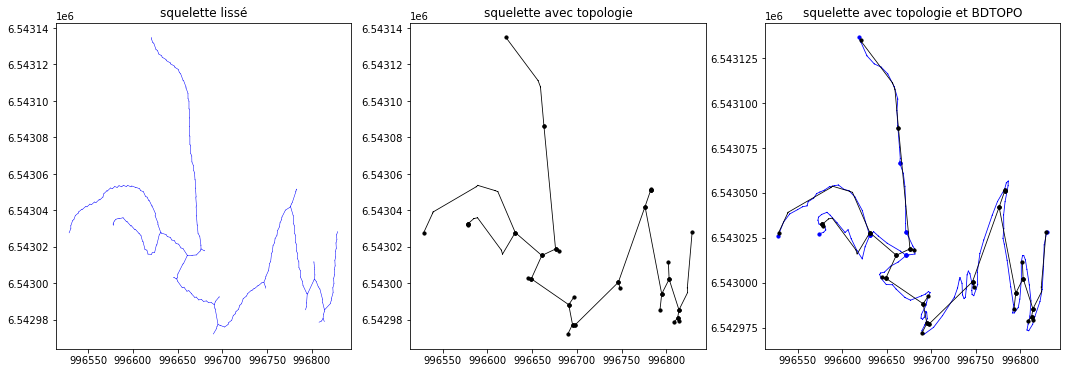

In [9]:
plt.figure(figsize=(18, 6))

ax1 = plt.subplot2grid((1, 3), (0, 0))
matPlotShapefile(RESPATH + 'network/', 'squelette_PT.shp', ax1)
ax1.set_title('squelette lissé')

ax2 = plt.subplot2grid((1, 3), (0, 1))
squelette.plot('k-', nodes='ko', size=0.8, append=ax2)
ax2.set_title('squelette avec topologie')

ax3 = plt.subplot2grid((1, 3), (0, 2))
network.plot(edges='b-', nodes='bo', size=0.8, append=ax3)
squelette.plot(edges='k-', nodes='ko', size=0.8, append=ax3)
ax3.set_title('squelette avec topologie et BDTOPO')

## Step 4 : Construction des géométries agrégées pour chaque arc du squelette

1. Attribue les points des traces brutes à chaque arc de la topologie
	- Recalage avec l’algorithme de Newson and Krumm (2009)
2. Reconstruit les bons morceaux de traces candidats pour chaque arc de la topologie
3. Agrégation des morceaux de traces
4. Conflation des traces fusionnées afin d’obtenir un réseau de mobilité

main_text  += "   - Attribue les points des traces brutes à chaque arc de la topologie \r\n"
    main_text  += "   - Reconstruit les bons morceaux de traces candidats pour chaque arc de la topologie\r\n"
    main_text  += "   - Agrégation des morceaux de traces\r\n"
    main_text  += "   - Conflation des traces fusionnées afin d’obtenir un réseau de mobilité\r\n"
    

In [10]:
from ofnp import createNetworkGeom

SEARCH = 30

createNetworkGeom(RESPATH, SEARCH, NB_OBS_MIN, DIST_MAX_2OBS)

Starting map-matching, aggregation, and conflation of GNSS trajectories.
Loading network ...
    Number of edges =  31
    Number of nodes =  34
    Total segment length of the network =  751.8854368273098
Loading collection of tracks ...


100% (34 of 34) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


    Number of tracks: 225
    Execution time (seconds): 0.36368823051452637
Starting map-matching ...
Map-matching preparation...
    Map-matching ended.
    Execution time (seconds): 1.0949132442474365
    Map-matching results restructuring completed.
    Map-matching results exported.
Starting construction of candidate trajectory segments for each topology edge ...
    Segment construction completed.
    Execution time (seconds): 1.3620212078094482
Starting aggregation ...
    Aggregation for arc number: 566
        Number of candidate tracks / number of sampled tracks 78 / 30
    Aggregation for arc number: 553
        Number of candidate tracks / number of sampled tracks 160 / 30
    Aggregation for arc number: 500
        Number of candidate tracks / number of sampled tracks 74 / 30
    Aggregation for arc number: 550
        Number of candidate tracks / number of sampled tracks 144 / 30
    Aggregation for arc number: 513
        Number of candidate tracks / number of sampled tra

### Visualisation du recalage sur le réseau

Text(0.5, 1.0, 'Résultat du map-matching')

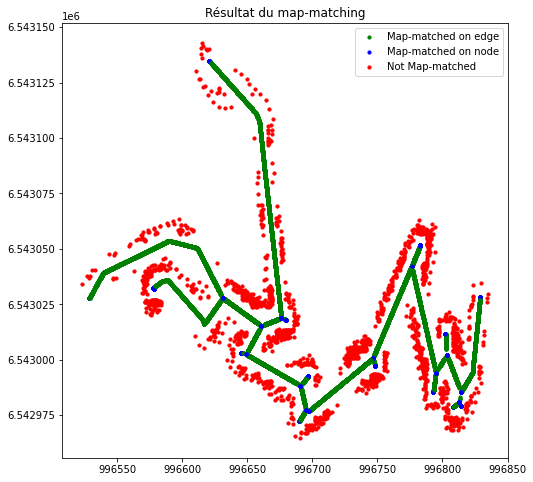

In [11]:
from ofnp import plotMM

plt.figure(figsize=(8, 8))

ax1 = plt.subplot2grid((1, 1), (0, 0))
plotMM(RESPATH, ax1)
ax1.set_title('Résultat du map-matching')

### Viusalisation des candidats pour l'agrégation

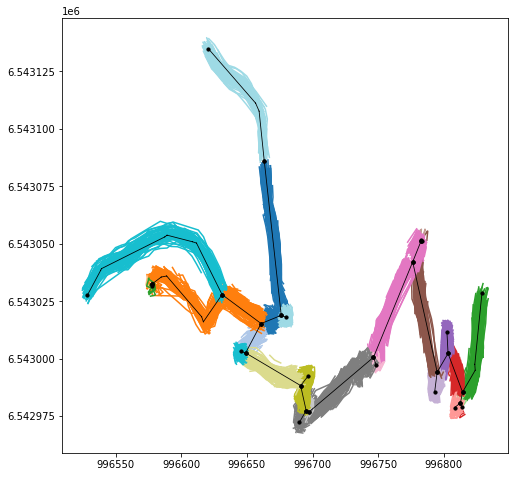

In [12]:
from ofnp import plotSegmentsConstruction

plt.figure(figsize=(8, 8))

ax1 = plt.subplot2grid((1, 1), (0, 0))
plotSegmentsConstruction(RESPATH, ax1, squelette)

### Visualisation de l'agrégation et de la conflation

Text(0.5, 1.0, 'CONFLATION')

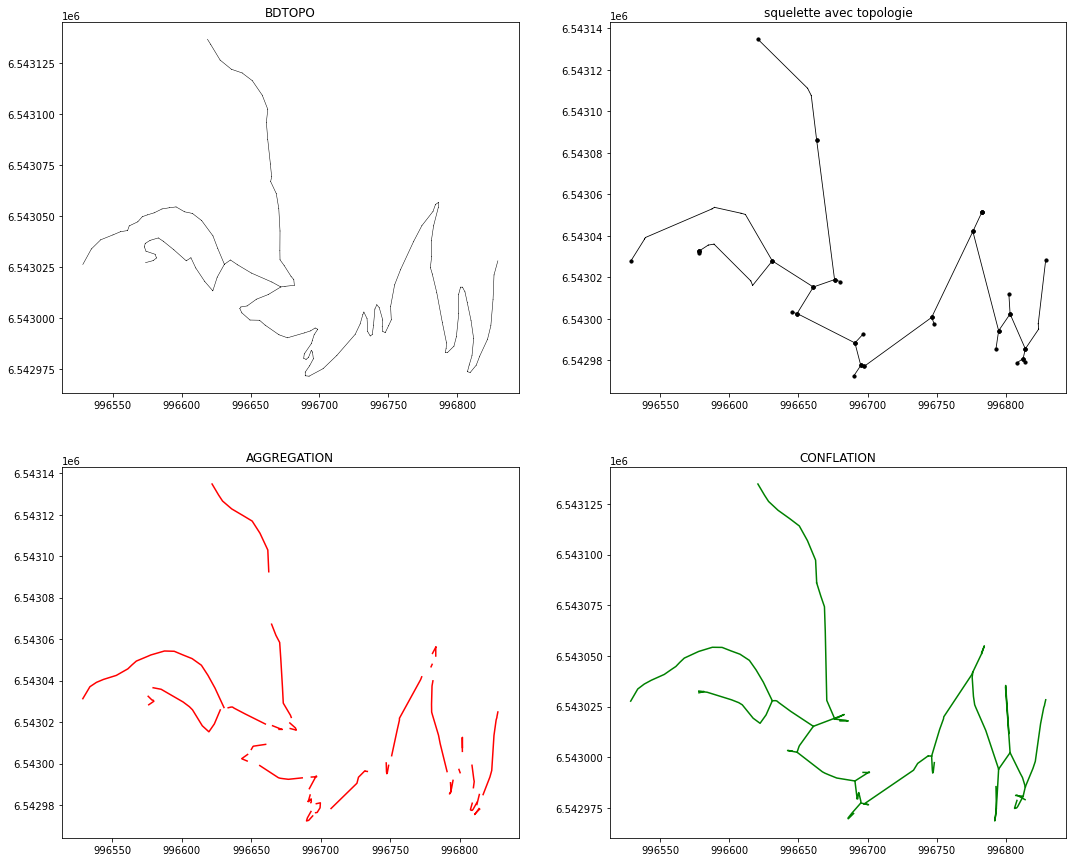

In [13]:
from ofnp import plotAggregation, plotConflation
import os

plt.figure(figsize=(18, 15))

# ---------------------------------------------------
ax1 = plt.subplot2grid((2, 2), (0, 0))
network.plot('k-', '', 'g-', 'r-', 0.5, ax1)
ax1.set_title('BDTOPO')

# ---------------------------------------------------
ax2 = plt.subplot2grid((2, 2), (0, 1))
squelette.plot('k-', nodes='ko', size=0.8, append=ax2)
ax2.set_title('squelette avec topologie')

# ---------------------------------------------------
ax3 = plt.subplot2grid((2, 2), (1, 0))
plotAggregation(RESPATH, ax3)
ax3.set_title('AGGREGATION')

# ---------------------------------------------------
ax4 = plt.subplot2grid((2, 2), (1, 1))
plotConflation(RESPATH, ax4)
ax4.set_title('CONFLATION')


## Indicateurs de qualité